# Notebook 03 — Baseline CNN

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

**Goal of this notebook:** build and train a simple CNN from scratch, using the pipeline from
Notebook 02. This is our **baseline** — a reasonable, unoptimized reference point. Notebook 04 will
test whether specific techniques (augmentation, BatchNorm, Dropout, etc.) actually improve on it.

No augmentation, no BatchNorm/Dropout, no transfer learning, and no test-set evaluation here —
those come later.


In [1]:
import sys

print(sys.version)

3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


## 1. Setup

**What are we doing?** Importing what we need, fixing the seed, and rebuilding the same
80/10/10 split and `train_ds`/`val_ds` from `clean_manifest.csv`.

**Why are we doing it?** Notebook 02 already explained and tested this pipeline in detail, so we
don't repeat that explanation here — we just recreate it in condensed form, using the exact same
split settings and seed, so this notebook can run on its own without depending on Notebook 02's
session still being open. The test split (`test_df`) is still produced by the split itself, but
no `test_ds` is built from it here — this notebook never touches the test set.


In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MANIFEST_PATH = Path("clean_manifest.csv")
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [3]:
# Rebuild the same split as Notebook 02 (same seed -> same split)
manifest_df = pd.read_csv(MANIFEST_PATH)

train_df, temp_df = train_test_split(
    manifest_df, test_size=0.2, stratify=manifest_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 19972 Val: 2497 Test: 2497


In [4]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


def make_dataset(split_df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((split_df["filepath"].values, split_df["label"].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=SEED)
    ds = ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
# Note: test_df exists (the 80/10/10 split includes a held-out test set), but we do not
# build a test_ds here -- the test set is not used at all in this notebook, and stays
# untouched until Notebook 06.

images, labels = next(iter(train_ds))
print("Batch shape:", images.shape)


Batch shape: (32, 180, 180, 3)


## 2. Understand the Baseline CNN

**What is a CNN, briefly?**

- **Convolutional layers** slide small filters over the image to learn visual patterns.
- **Early layers** tend to learn simple patterns (edges, colors, textures).
- **Deeper layers** combine those into more complex patterns (shapes, fur, ears...).
- **Pooling** shrinks the spatial size while keeping the most useful information — this also
  reduces computation.
- **Dense layers** at the end take all the learned features and make the final Cat/Dog decision.

That's all we need to know before building one.


## 3. Build the Baseline CNN

**What are we doing?** Building a simple CNN from scratch with three convolution+pooling blocks,
then a dense layer, then a single output neuron.

**Why are we doing it?** This is a deliberately plain architecture — no BatchNorm, no Dropout, no
pretrained weights. It exists to give us an honest reference point to compare later improvements
against, not to be the best possible model.


In [5]:
model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),  # scales pixel values from [0, 255] to [0, 1]

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])


## 4. Explain the Architecture

**What are we doing?** Looking at the model summary.

**Why are we doing it?** Confirms the shapes flowing through the network match what we expect
before we spend time training it.


In [6]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

**What the pieces mean:**
- `Rescaling(1./255)` — converts pixel values from 0–255 to 0–1, which helps training stability.
- **filters** (32, 64, 128) — how many different patterns each layer can learn; we use more filters
  in deeper layers since patterns get more complex.
- **kernel size (3×3)** — the size of the small window that slides over the image.
- **ReLU activation** — a simple rule that lets the network learn non-linear patterns.
- **MaxPooling2D** — shrinks the image size, keeping the strongest signal in each region.
- **Flatten** — turns the final 2D feature maps into a single long vector.
- **Dense(128)** — combines all learned features to help make the final decision.
- **sigmoid output** — squashes the final value into a 0–1 range, which we read as "probability of
  being a Dog" (since Dog = 1).


## 5. Compile the Model

**What are we doing?** Telling Keras how to train the model.

**Why are we doing it?**
- `adam` — controls how the model's weights are updated after each batch.
- `binary_crossentropy` — the standard loss function for a two-class (Cat vs Dog) problem.
- `accuracy` — the simplest metric to track: percentage of correct predictions.


In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


## 6. Train the Baseline

**What are we doing?** Training for up to 15 epochs, but stopping early if validation loss stops
improving, and keeping only the best-performing version of the model.

**Why are we doing it?**
- `EarlyStopping` avoids wasting time training once the model stops genuinely improving, and
  `restore_best_weights=True` makes sure we end up with the best epoch, not just the last one.
- `ModelCheckpoint` saves that best version to disk so we can reload it later without retraining.
- The exact epoch count doesn't matter much here — early stopping decides when to stop.

**Note on shuffling:** `train_ds` was already shuffled when it was built (Section 1).
Keras's `model.fit()` defaults to `shuffle=True` even if you don't write it explicitly, and with
a `tf.data.Dataset` input that default triggers a warning saying it will be ignored. To avoid
that noisy (but harmless) warning, we explicitly pass `shuffle=False` below — the dataset is
already shuffled, so this doesn't change training behavior at all, it just silences the warning.

We also time the training here, since training time is one of the things we'll compare against
later experiments in Notebook 04.


In [8]:
EPOCHS = 15
MODEL_PATH = "baseline_cnn.keras"

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

checkpoint = callbacks.ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
)

start_time = time.time()

# train_ds is already shuffled (Section 1). shuffle=False here just silences Keras's
# harmless "shuffle=True will be ignored" warning -- it has no effect on training itself.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    shuffle=False,
    callbacks=[early_stopping, checkpoint],
)

training_time_seconds = time.time() - start_time


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 498ms/step - accuracy: 0.6420 - loss: 0.6232 - val_accuracy: 0.7389 - val_loss: 0.5181
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 275s 440ms/step - accuracy: 0.7726 - loss: 0.4770 - val_accuracy: 0.7821 - val_loss: 0.4545
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 268s 428ms/step - accuracy: 0.8229 - loss: 0.3871 - val_accuracy: 0.8170 - val_loss: 0.3936
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - accuracy: 0.8767 - loss: 0.2903 - val_accuracy: 0.7901 - val_loss: 0.4671
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 246s 394ms/step - accuracy: 0.9256 - loss: 0.1844 - val_accuracy: 0.8206 - val_loss: 0.4458
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 267s 427ms/step - accuracy: 0.9661 - loss: 0.0903 - val_accuracy: 0.8230 - val_loss: 0.6271
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 278s 445ms/step - accuracy: 0.9861 - loss: 0.0413 - val_accuracy: 0.8138 - val_loss: 0.7031
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 419ms/step - accuracy: 0.9861 -

## 7. Record Training Time

**What are we doing?** Reporting how long training took, and how many epochs actually ran.

**Why are we doing it?** Notebook 04 will compare training time across experiments — a technique
that gives a tiny accuracy improvement but doubles training time is a trade-off worth knowing about.


In [9]:
epochs_completed = len(history.history["loss"])

print(f"Training time: {training_time_seconds:.1f} seconds ({training_time_seconds/60:.1f} minutes)")
print(f"Epochs completed: {epochs_completed} (max was {EPOCHS})")


Training time: 4167.6 seconds (69.5 minutes)
Epochs completed: 15 (max was 15)


## 8. Plot Training History

**What are we doing?** Plotting training vs validation accuracy, and training vs validation loss.

**Why are we doing it?** These curves tell us whether the model is learning well, and whether it's
overfitting. **Overfitting** means training performance keeps improving while validation
performance stalls or gets worse — the model is memorizing training images rather than learning
patterns that generalize.


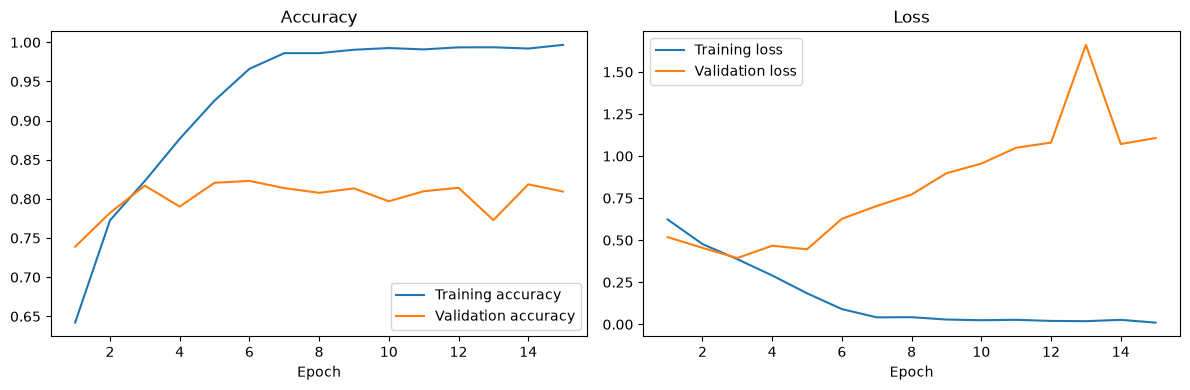

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training accuracy")
plt.plot(epochs_range, val_acc, label="Validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


## 9. Baseline Validation Evaluation

**What are we doing?** Evaluating the model on the validation set, using the best
validation-loss weights — already restored into `model` by
`EarlyStopping(restore_best_weights=True)` during training. No separate loading from disk is
needed for this.

**Why are we doing it?** This gives us the baseline number that later notebooks will compare
against. We use validation, not test — **the test set stays untouched until Notebook 06.**


In [11]:
val_loss_final, val_accuracy_final = model.evaluate(val_ds)

print(f"Validation loss: {val_loss_final:.4f}")
print(f"Validation accuracy: {val_accuracy_final:.4f}")


79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.8170 - loss: 0.3936
Validation loss: 0.3936
Validation accuracy: 0.8170


## 10. Save Baseline Results

**What are we doing?** Recording a small summary of this run.

**Why are we doing it?** Notebook 04 will build a comparison table across experiments — this row
is the reference point everything else gets compared to.


In [12]:
baseline_results = {
    "Model name": "Baseline CNN",
    "Validation accuracy": round(float(val_accuracy_final), 4),
    "Validation loss": round(float(val_loss_final), 4),
    "Training time (seconds)": round(training_time_seconds, 1),
    "Epochs completed": epochs_completed,
}

pd.Series(baseline_results, name="Value").to_frame()


,Value
Model name,Baseline CNN
Validation accuracy,0.817
Validation loss,0.3936
Training time (seconds),4167.6
Epochs completed,15


## 11. Final Conclusion

We built a simple CNN from scratch (three Conv2D+MaxPooling blocks, one dense layer) and trained
it on the cleaned Cat vs Dog dataset. This is our **baseline** — no augmentation, no BatchNorm, no
Dropout, no transfer learning. We recorded its validation accuracy, validation loss, and training
time, and looked at its training curves for early signs of overfitting.

Notebook 04 will use this baseline as the reference point when testing whether specific techniques
(data augmentation, BatchNorm, Dropout, a deeper architecture, different resolutions) genuinely
improve generalization — or not.
